# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

## Setup and load data
Add the project root to the import path, load the TXT dataset, and split into train/test for modeling.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

type = "SCZ"
clumping = "0.0001"

data_path = Path(f"../../data/tmpDATA-Leon/donnees_MRI_{type}_only_variants_clumping_p_thr_{clumping}all.txt")

df = load_txt(data_path)
X_train, y_train, X_test, y_test = preprocess(df=df, target=f"Z_scores_{type}", testsize = 0.2)


## Train RRFS and rank features
Run the teacher/student training across seeds, collect feature importances, and plot losses.

Training Teacher (Autoencoder)...


/Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/model/RRFS.py:85: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y.reshape(-1, 1)))



Training Student (Feature Selector)...
Training Teacher (Autoencoder)...

Training Student (Feature Selector)...
Training Teacher (Autoencoder)...

Training Student (Feature Selector)...
Training Teacher (Autoencoder)...

Training Student (Feature Selector)...
Training Teacher (Autoencoder)...

Training Student (Feature Selector)...


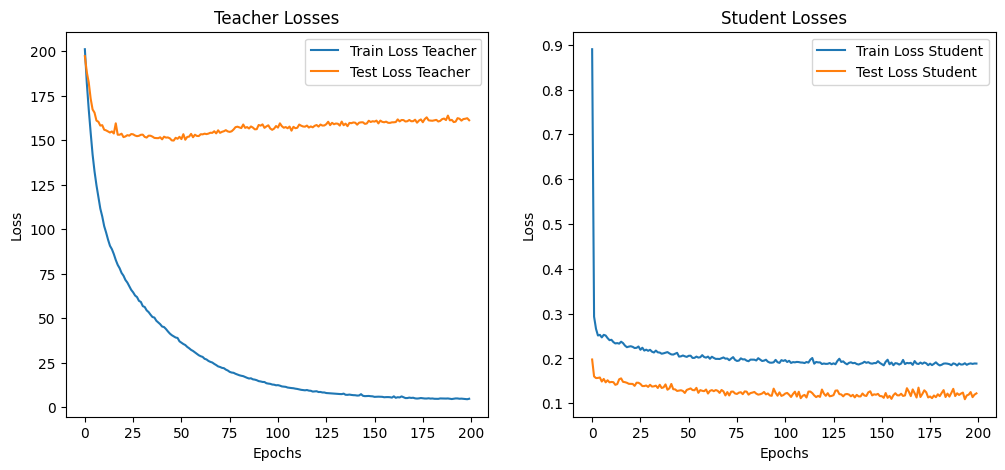

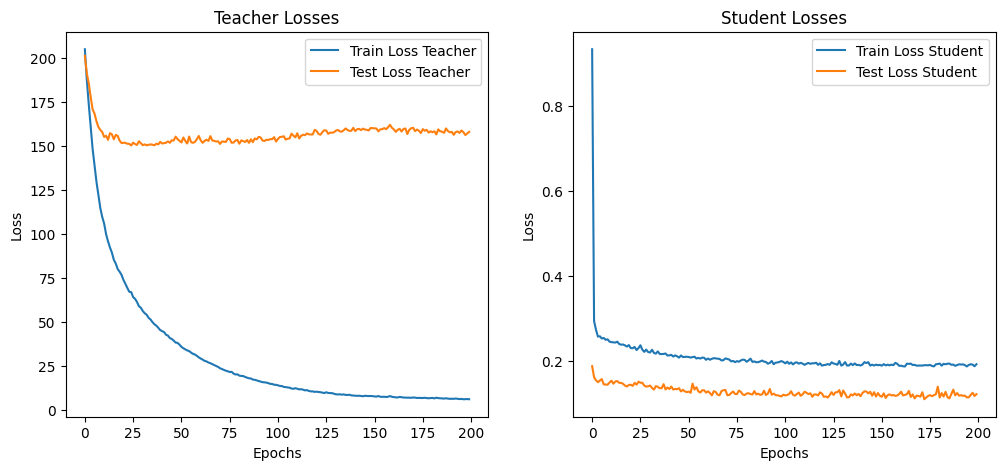

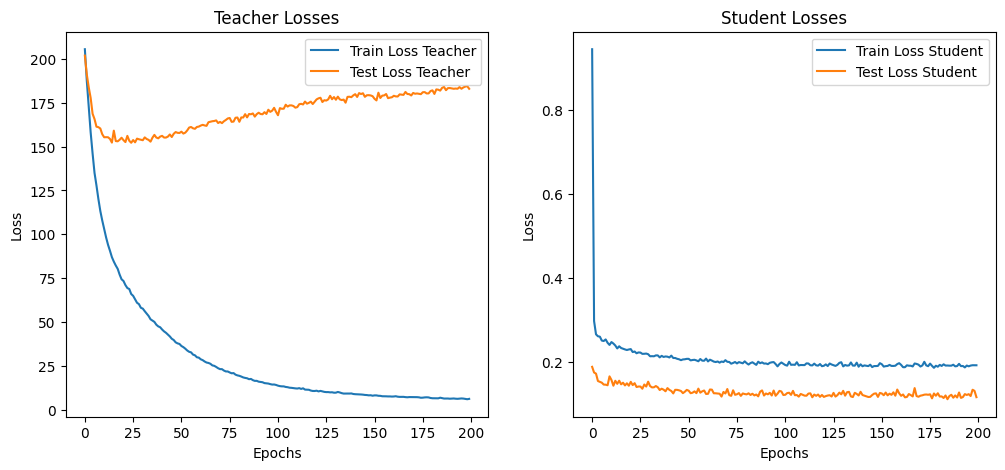

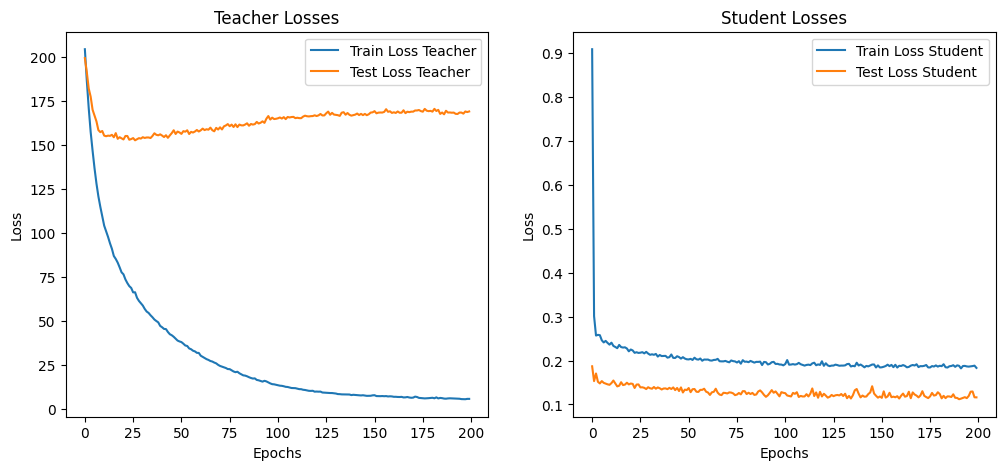

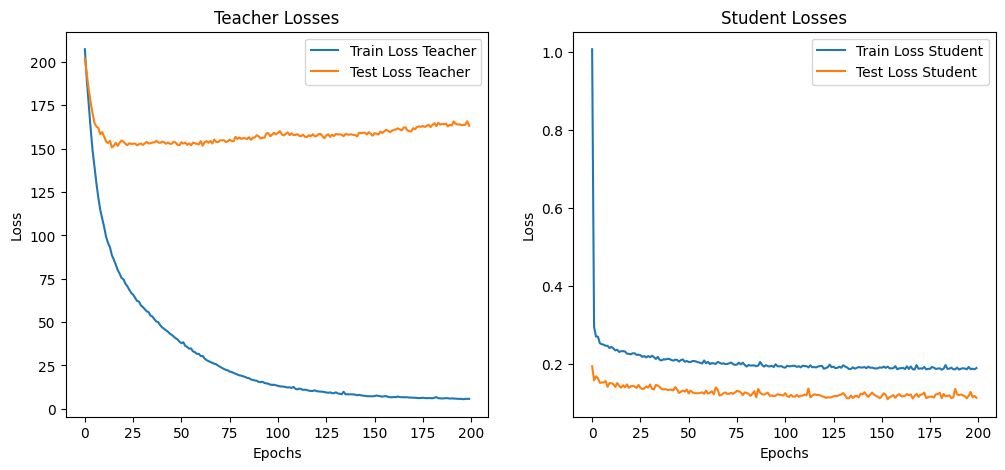

In [2]:
from model import DeepFeatureSelection
import numpy as np

top_features = {}

hidden_dim = 10

teacher_epochs = 200
teacher_regression_weight = 10
teacher_reconstruction_weight = 1
teacher_lr = 0.001

student_epochs = 200
student_lr = 0.001

train_losses_teacher_all = []
test_losses_teacher_all = []

train_losses_student_all = []
test_losses_student_all = []

for seed in range(5):
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    import random
    random.seed(seed)

    rrfs = DeepFeatureSelection(input_dim=X_train.shape[1], hidden_dim=hidden_dim, l1_reg=0.01)
    # 1. Train Teacher
    train_losses, test_losses = rrfs.train_teacher(X_train, y_train.values, 
                                                   X_test, y_test.values, 
                                                   epochs=teacher_epochs, 
                                                   recon_weight=teacher_reconstruction_weight, 
                                                   reg_weight=teacher_regression_weight,
                                                   lr=teacher_lr)
    train_losses_teacher_all.append(train_losses)
    test_losses_teacher_all.append(test_losses)

    # 2. Train Student
    train_losses, test_losses = rrfs.train_student(X_train, 
                                                   epochs=student_epochs, 
                                                   batch_size=32, 
                                                   lr=student_lr)
    train_losses_student_all.append(train_losses)
    test_losses_student_all.append(test_losses)

    # 3. Get Scores
    scores = rrfs.get_feature_importance()

    top = (np.argsort(scores)[::-1])
    for idx in top:
        if idx in top_features:
            top_features[idx] += 1
        else:
            top_features[idx] = 1

    # plot losses
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses_teacher_all[-1], label='Train Loss Teacher')
    plt.plot(test_losses_teacher_all[-1], label='Test Loss Teacher')
    plt.title('Teacher Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()    

    plt.subplot(1, 2, 2)
    plt.plot(train_losses_student_all[-1], label='Train Loss Student')
    plt.plot(test_losses_student_all[-1], label='Test Loss Student')
    plt.title('Student Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()    

## Aggregate top features across runs
Compute the top 100 most frequently selected features from all seeds.

In [3]:
# extract top 100 features overall
import heapq

# Assume 'top_features' looks like {feature_index: count, ...}
# top_features = {0: 45, 1: 120, 2: 10, ...}

# Get top 100 (key, value) pairs based on the values
top_100_pairs = heapq.nlargest(100, top_features.items(), key=lambda item: item[1])

# Extract just the indices (keys)
top_100_indices = [pair[0] for pair in top_100_pairs]
top_100_counts = [pair[1] for pair in top_100_pairs]

print(top_100_indices)
print(top_100_counts)

[np.int64(428), np.int64(790), np.int64(799), np.int64(198), np.int64(982), np.int64(117), np.int64(3), np.int64(992), np.int64(974), np.int64(1005), np.int64(828), np.int64(195), np.int64(453), np.int64(5), np.int64(92), np.int64(76), np.int64(75), np.int64(781), np.int64(418), np.int64(901), np.int64(259), np.int64(947), np.int64(671), np.int64(635), np.int64(463), np.int64(911), np.int64(443), np.int64(68), np.int64(66), np.int64(892), np.int64(870), np.int64(605), np.int64(389), np.int64(755), np.int64(356), np.int64(261), np.int64(160), np.int64(255), np.int64(451), np.int64(1000), np.int64(822), np.int64(826), np.int64(682), np.int64(703), np.int64(82), np.int64(763), np.int64(840), np.int64(27), np.int64(833), np.int64(159), np.int64(4), np.int64(623), np.int64(981), np.int64(834), np.int64(285), np.int64(700), np.int64(857), np.int64(50), np.int64(923), np.int64(29), np.int64(455), np.int64(980), np.int64(860), np.int64(360), np.int64(252), np.int64(415), np.int64(376), np.int6

## Helper: select top-N feature indices
Define a utility to return the indices of the top-N features.

In [4]:
# extract top 100 features overall
import heapq

# Assume 'top_features' looks like {feature_index: count, ...}
# top_features = {0: 45, 1: 120, 2: 10, ...}
def get_top_n_features(top_features, n=10):
    # Get top 100 (key, value) pairs based on the values
    top_n_pairs = heapq.nlargest(n, top_features.items(), key=lambda item: item[1])

    # Extract just the indices (keys)
    top_n_indices = [pair[0] for pair in top_n_pairs]

    return top_n_indices

## Helper: linear regression evaluation
Compute $R^2$ using a linear regression model on the top-N features.

In [5]:
def get_r2_score_regression(X_train, y_train, X_test, y_test, top_features, n=10):
    top_n_indices = get_top_n_features(top_features, n)

    # run regression with only top features
    X_test_top = X_test[:, top_n_indices]
    X_train_top = X_train[:, top_n_indices]

    from sklearn import linear_model 
    regr = linear_model.LinearRegression()
    regr.fit(X_train_top, y_train)

    r2_score = regr.score(X_test_top, y_test)
    return r2_score

## Helper: random forest evaluation
Compute $R^2$ using a random forest regressor on the top-N features.

In [6]:
def get_r2_score_random_forest(X_train, y_train, X_test, y_test, top_features, n=10):
    top_n_indices = get_top_n_features(top_features, n)

    # run regression with only top features
    X_test_top = X_test[:, top_n_indices]
    X_train_top = X_train[:, top_n_indices]

    from sklearn.ensemble import RandomForestRegressor
    regr = RandomForestRegressor(n_estimators=100, random_state=0)
    regr.fit(X_train_top, y_train)

    r2_score = regr.score(X_test_top, y_test)
    return r2_score

## Evaluate $R^2$ vs. number of top features
Run linear and random-forest regressors for different top-N sizes.

In [7]:
for n in [10, 20, 50, 100, 200, 500, 1000]:
    r2 = get_r2_score_regression(X_train, y_train, X_test, y_test, top_features, n)
    print(f"R2 score with top {n} features: {r2}")

R2 score with top 10 features: 0.1330654575198852
R2 score with top 20 features: 0.16866410628383965
R2 score with top 50 features: 0.1912216184967851
R2 score with top 100 features: 0.22686517515041138
R2 score with top 200 features: 0.21886733923301294
R2 score with top 500 features: 0.24331528772980837
R2 score with top 1000 features: 0.22034720010888253


## Evaluate random forest baseline
Repeat the evaluation using a random forest regressor.

In [9]:
for n in [10, 20, 50, 100, 200, 500, 1000]:
    r2 = get_r2_score_random_forest(X_train, y_train, X_test, y_test, top_features, n)
    print(f"R2 score with top {n} features: {r2}")

R2 score with top 10 features: 0.1405387535891397
R2 score with top 20 features: 0.18130356177809515
R2 score with top 50 features: 0.21021455434982073
R2 score with top 100 features: 0.23782978577701785
R2 score with top 200 features: 0.2461361967885074
R2 score with top 500 features: 0.2581140044962875
R2 score with top 1000 features: 0.2694221418722801


## Build PyTorch data loaders
Create datasets and loaders using the top 100 features.

In [20]:
from torch.utils.data import DataLoader

top_indices = get_top_n_features(top_features, n=100)

X_train_top = X_train[:, top_indices]
X_test_top = X_test[:, top_indices]

train_loader = DataLoader(GWASDataset(X_train_top, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test_top, y_test), batch_size=32, shuffle=False)

## Define the DNN model
Instantiate a small neural network for regression.

In [21]:
from model import DNN

model = DNN(input_dim=X_train_top.shape[1], hidden_dims=[512, 512], output_dim=1, dropout=0.2)
print(model)

DNN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=1, bias=True)
  )
)


## Train the DNN
Optimize the model and track train/test loss per epoch.

In [22]:
from torch import nn, optim
import torch

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
test_losses = []
 
for epoch in range(500):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        # l2 regularization
        loss = criterion(predictions, batch_y) + 0.0001 * sum(param.pow(2.0).sum() for param in model.parameters())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))
    #print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y.view(-1, 1))
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(average_test_loss)
    #print(f"Test Mean Squared Error: {average_test_loss:.4f}")

## Plot training curves
Visualize train vs. test loss over epochs.

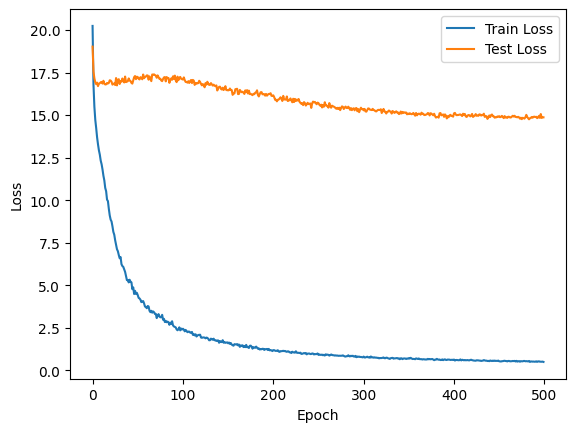

In [23]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [24]:
# get the r2 score of the dnn model on test test
preds = model(torch.tensor(X_test_top, dtype=torch.float32)).detach().numpy()
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)
print(f"R2 score of DNN model on test set: {r2}")

R2 score of DNN model on test set: 0.3292186581472277
